# A neural network that reads raw light curves

### ZTF Summer School — building a sequence classifier from scratch

No prior neural-network experience assumed. In one hour you will build, train
and honestly evaluate a deep classifier that reads ZTF light curves **as they
are** — irregular, multi-band, different length for every object — with no
hand-crafted features anywhere.

The model is small enough to train on a laptop CPU in a few minutes, and every
line of it is in this notebook.

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

sys.path.insert(0, "../..")
from flare import BROAD_CLASSES
from flare import data as D
from flare.taxonomy import ID2BROAD_ID

DATA_DIR = os.environ.get("FLARE_DATA",
    "/work/hdd/bcrv/ffontinelenunes/data/AppleCider/photo_events")
D.DATA_DIR = __import__("pathlib").Path(DATA_DIR)

CLASS_COLOR = {"SNI": "#0072B2", "SNII": "#E69F00", "CV": "#009E73",
               "AGN": "#CC79A7", "TDE": "#D55E00"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
torch.manual_seed(0); np.random.seed(0)
print("Setup OK — torch", torch.__version__)

Setup OK — torch 2.10.0+cu128


## 1. The data, and the three properties that will shape the model

Look at the *shape* of the data, not the astronomy, for a moment.

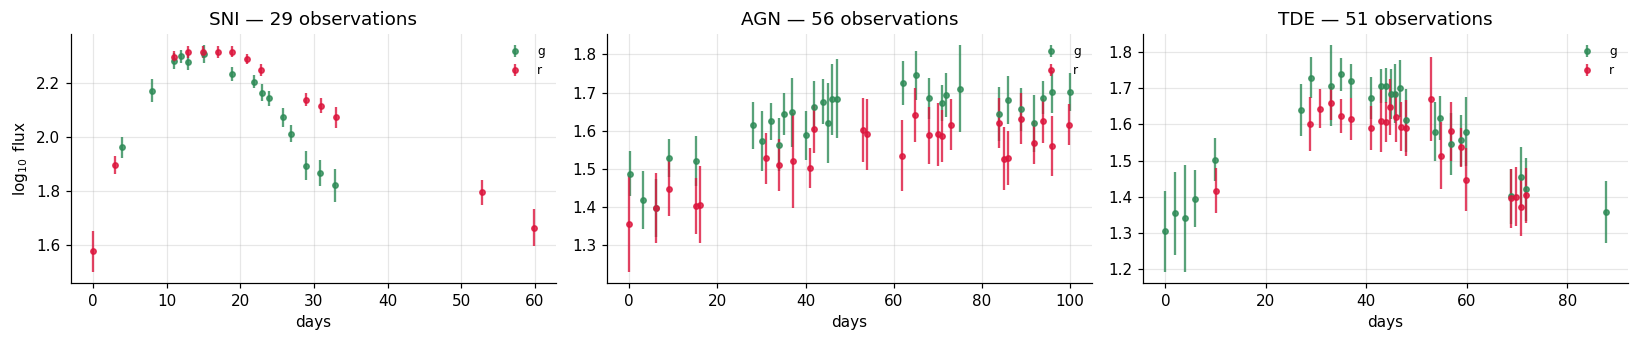

observations per object: min=1, median=72, max=2404


In [2]:
manifest = D.load_manifest("train")
manifest["broad"] = manifest["label"].map(lambda x: BROAD_CLASSES[ID2BROAD_ID[int(x)]])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, cls in zip(axes, ["SNI", "AGN", "TDE"]):
    row = manifest[manifest.broad == cls].sort_values("n_events").iloc[
        len(manifest[manifest.broad == cls]) // 2]
    arr = D.load_events(row.filepath)
    bands = D.reconstruct_bands(arr)
    for name, colr in [("g", "seagreen"), ("r", "crimson")]:
        if name in bands:
            ax.errorbar(bands[name].t, bands[name].logflux,
                        yerr=bands[name].logflux_err, fmt="o", ms=3.5,
                        color=colr, alpha=0.8, label=name)
    ax.set_title(f"{cls} — {len(arr)} observations")
    ax.set_xlabel("days"); ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel(r"$\log_{10}$ flux")
plt.tight_layout(); plt.show()
print(f"observations per object: min={manifest.n_events.min()}, "
      f"median={int(manifest.n_events.median())}, max={manifest.n_events.max()}")

Three properties, three design problems:

| # | Property | Problem for a model | Our answer |
|---|---|---|---|
| **P1** | Different number of observations per object, at irregular times | the input is not a fixed-size vector; "observation 7" is a different time for every object | read in order with a memory; give the model the **clock** (Δt is an input) |
| **P2** | g / r / i filters interleave in one stream | the same flux means different things in different bands | the band **re-tunes** the network (FiLM) |
| **P3** | one label per object, whatever its length | many per-night vectors must become one | the model **learns where to look** (attention pooling) |

A network with a fixed number of inputs (the kind you may have seen before)
fails at P1 immediately: padding to the longest object misaligns time, and
resampling onto a grid invents data inside week-long gaps. The escape is a
**recurrent** network: read one observation at a time, carrying a memory
vector; two learned gates decide, each step, how much old memory to keep and
how much of the new observation to write. That cell is the **GRU**.

## 2. The whole architecture, in ~30 lines

Read it against P1-P3 — every block answers one of them.

In [3]:
class LightCurveGRU(nn.Module):
    '''FiLM-conditioned GRU with attention pooling, for raw event streams.'''

    def __init__(self, d=48, n_layers=2, n_classes=5, use_film=True):
        super().__init__()
        self.use_film = use_film
        self.embed = nn.Linear(4, d)        # dt_start, dt_prev, flux, err  (P1)
        self.film  = nn.Linear(3, 2 * d)    # band one-hot -> per-unit scale+shift (P2)
        self.gru   = nn.GRU(d, d, num_layers=n_layers, batch_first=True)
        self.score = nn.Linear(d, 1)        # attention: one score per night (P3)
        self.head  = nn.Linear(d, n_classes)

    def forward(self, x, band, pad):
        h = self.embed(x)                            # (batch, nights, d)
        if self.use_film:
            gamma, beta = self.film(band).chunk(2, -1)
            h = h * (1 + gamma) + beta               # the band re-tunes h  (P2)
        h, _ = self.gru(h)                           # memory through time  (P1)
        a = self.score(h).squeeze(-1)
        a = a.masked_fill(pad, -1e9).softmax(-1)     # padded nights: weight 0
        z = (h * a.unsqueeze(-1)).sum(1)             # learned summary      (P3)
        return self.head(z), a

print(f"{sum(p.numel() for p in LightCurveGRU().parameters()):,} parameters")

29,142 parameters


## 3. From npz files to padded tensors

Objects have different lengths, so a batch pads the short ones with zeros and
carries a `pad` mask telling the attention to ignore those slots. Flux is
standardized with **train-only** statistics — the golden rule applies to
normalisation too.

In [4]:
CAP = 120     # cap the sequence length to keep CPU training quick

def build_tensors(df, stats=None):
    xs, bands, ys, lens = [], [], [], []
    for _, row in df.iterrows():
        arr = D.load_events(row.filepath)[:CAP]
        x = np.stack([np.log1p(arr[:, D.COL["dt"]]),
                      np.log1p(arr[:, D.COL["dt_prev"]]),
                      arr[:, D.COL["logflux"]],
                      arr[:, D.COL["logflux_err"]]], 1).astype(np.float32)
        b = np.eye(3, dtype=np.float32)[np.clip(arr[:, D.COL["band_id"]].astype(int), 0, 2)]
        xs.append(x); bands.append(b)
        ys.append(ID2BROAD_ID[int(row.label)]); lens.append(len(arr))
    L = max(lens)
    X  = np.zeros((len(xs), L, 4), np.float32)
    Bd = np.zeros((len(xs), L, 3), np.float32)
    P  = np.ones((len(xs), L), bool)
    for i, (x, b, n) in enumerate(zip(xs, bands, lens)):
        X[i, :n], Bd[i, :n], P[i, :n] = x, b, False
    if stats is None:
        stats = (X[..., 2][~P].mean(), X[..., 2][~P].std(),
                 X[..., 3][~P].mean(), X[..., 3][~P].std())
    fm, fs, em, es = stats
    X[..., 2] = np.where(P, 0, (X[..., 2] - fm) / fs)
    X[..., 3] = np.where(P, 0, (X[..., 3] - em) / es)
    T = torch.tensor
    return (T(X), T(Bd), T(P), T(np.array(ys))), stats

mf = {s: D.filter_manifest_quality(D.load_manifest(s))[0] for s in ["train", "val", "test"]}
sub = (mf["train"]
       .assign(broad=lambda d: d.label.map(lambda x: ID2BROAD_ID[int(x)]))
       .groupby("broad", group_keys=False)
       .apply(lambda g: g.sample(min(len(g), 700), random_state=0)))
print(f"training subset: {len(sub)} objects (all rare-class examples kept)")

t0 = time.time()
train_T, stats = build_tensors(sub)
val_T,  _ = build_tensors(mf["val"], stats)
test_T, _ = build_tensors(mf["test"], stats)
print(f"tensors built in {time.time()-t0:.0f}s — train {tuple(train_T[0].shape)}")

training subset: 2493 objects (all rare-class examples kept)


tensors built in 15s — train (2493, 120, 4)


## 4. Training

Training is one idea repeated: predict, measure the error (the *loss*), nudge
every weight slightly against its share of the blame, repeat. `Adam` is
gradient descent with per-weight step sizes; the class weights stop 4,000 SNI
from drowning 47 TDEs.

In [5]:
def train_model(model, train_T, val_T, epochs=10, bs=128, lr=3e-3):
    X, Bd, P, y = train_T
    counts = torch.bincount(y, minlength=5).float()
    wclass = (len(y) / (5 * counts)).clamp(max=30)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss(weight=wclass)
    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(len(y))
        tot = 0.0
        for i in range(0, len(y), bs):
            ix = perm[i:i + bs]
            logits, _ = model(X[ix], Bd[ix], P[ix])
            loss = lossf(logits, y[ix])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(ix)
        if ep % 2 == 0 or ep == 1:
            model.eval()
            with torch.no_grad():
                lv, _ = model(*val_T[:3])
                acc = (lv.argmax(1) == val_T[3]).float().mean()
            print(f"  epoch {ep:2d}: train loss {tot/len(y):.3f}   val acc {acc:.3f}")
    return model

torch.manual_seed(0)
net = LightCurveGRU(use_film=True)
net = train_model(net, train_T, val_T, epochs=10)

  epoch  1: train loss 1.420   val acc 0.456


  epoch  2: train loss 1.195   val acc 0.605


  epoch  4: train loss 0.954   val acc 0.643


  epoch  6: train loss 0.733   val acc 0.710


  epoch  8: train loss 0.579   val acc 0.736


  epoch 10: train loss 0.525   val acc 0.663


## 5. Does the band conditioning actually matter?

Never take an architectural choice on faith — switch it off and measure.

In [6]:
torch.manual_seed(0)
blind = LightCurveGRU(use_film=False)
print("band-blind GRU (FiLM off):")
blind = train_model(blind, train_T, val_T, epochs=10)

band-blind GRU (FiLM off):


  epoch  1: train loss 1.414   val acc 0.485


  epoch  2: train loss 1.194   val acc 0.613


  epoch  4: train loss 1.012   val acc 0.585


  epoch  6: train loss 0.868   val acc 0.682


  epoch  8: train loss 0.788   val acc 0.698


  epoch 10: train loss 0.677   val acc 0.658


## 6. The full evaluation report

Accuracy alone is nearly useless with classes this imbalanced. Report the full
picture: balanced accuracy, macro F1, per-class precision/recall, ranking
quality (macro AUPRC), the confusion matrix, and whether the probabilities are
*honest* (a reliability diagram + expected calibration error).

In [7]:
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             f1_score, average_precision_score)

def full_report(model, T, name):
    model.eval()
    with torch.no_grad():
        logits, attn = model(*T[:3])
        proba = logits.softmax(-1).numpy()
    y = T[3].numpy(); pred = proba.argmax(1)
    auprc = np.mean([average_precision_score((y == c).astype(int), proba[:, c])
                     for c in range(5)])
    print(f"===== {name} =====")
    print(f"accuracy {(pred == y).mean():.4f} | balanced "
          f"{balanced_accuracy_score(y, pred):.4f} | macro F1 "
          f"{f1_score(y, pred, average='macro'):.4f} | macro AUPRC {auprc:.4f}\n")
    print(classification_report(y, pred, target_names=BROAD_CLASSES, digits=3))
    return proba, attn

proba_blind, _ = full_report(blind, test_T, "band-blind GRU")
proba_net, attn = full_report(net, test_T, "FiLM-GRU")

===== band-blind GRU =====
accuracy 0.6806 | balanced 0.7003 | macro F1 0.5331 | macro AUPRC 0.6852

              precision    recall  f1-score   support

         SNI      0.941     0.749     0.834       886
        SNII      0.445     0.539     0.488       219
          CV      0.390     0.934     0.550        91
         AGN      0.988     0.612     0.756       774
         TDE      0.019     0.667     0.038         9

    accuracy                          0.681      1979
   macro avg      0.557     0.700     0.533      1979
weighted avg      0.875     0.681     0.749      1979



===== FiLM-GRU =====
accuracy 0.6943 | balanced 0.7483 | macro F1 0.5620 | macro AUPRC 0.7050

              precision    recall  f1-score   support

         SNI      0.948     0.634     0.760       886
        SNII      0.403     0.648     0.497       219
          CV      0.506     0.934     0.656        91
         AGN      0.978     0.747     0.847       774
         TDE      0.025     0.778     0.049         9

    accuracy                          0.694      1979
   macro avg      0.572     0.748     0.562      1979
weighted avg      0.875     0.694     0.757      1979



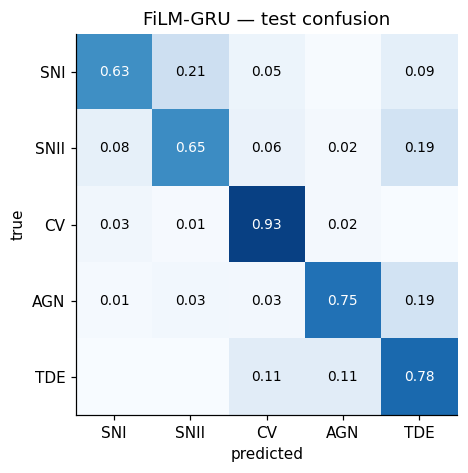

In [8]:
# confusion matrix (row-normalised)
y = test_T[3].numpy(); pred = proba_net.argmax(1)
cm = np.array([[np.mean(pred[y == t] == p) if (y == t).sum() else 0
                for p in range(5)] for t in range(5)])
fig, ax = plt.subplots(figsize=(5, 4.4))
ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for t in range(5):
    for p in range(5):
        if cm[t, p] >= 0.01:
            ax.text(p, t, f"{cm[t, p]:.2f}", ha="center", va="center",
                    color="white" if cm[t, p] > 0.6 else "black", fontsize=9)
ax.set_xticks(range(5)); ax.set_xticklabels(BROAD_CLASSES)
ax.set_yticks(range(5)); ax.set_yticklabels(BROAD_CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.grid(False)
ax.set_title("FiLM-GRU — test confusion")
plt.tight_layout(); plt.show()

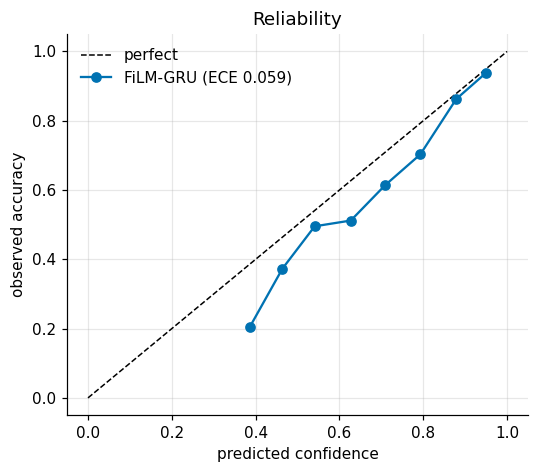

An over-confident classifier sits below the diagonal. Keep this plot in mind in the FLARE notebook, where calibration is a design goal.


In [9]:
# reliability: does 90% confident mean 90% right?
def reliability(y, p, n_bins=12):
    conf, pred = p.max(1), p.argmax(1)
    correct = (pred == y).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys = [], []
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 8:
            xs.append(conf[m].mean()); ys.append(correct[m].mean())
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return np.array(xs), np.array(ys), ece

fig, ax = plt.subplots(figsize=(5, 4.4))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
xs, ys, ece = reliability(y, proba_net)
ax.plot(xs, ys, "o-", color="#0072B2", label=f"FiLM-GRU (ECE {ece:.3f})")
ax.set_xlabel("predicted confidence"); ax.set_ylabel("observed accuracy")
ax.legend(frameon=False); ax.set_title("Reliability")
plt.tight_layout(); plt.show()
print("An over-confident classifier sits below the diagonal. Keep this plot in"
      " mind in the FLARE notebook, where calibration is a design goal.")

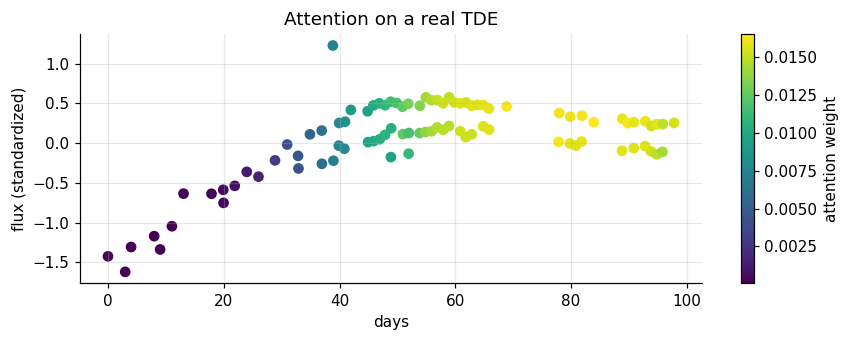

In [10]:
# where did the network look? (attention weights on a real TDE)
tde_ix = np.where(y == 4)[0]
i = int(tde_ix[0]) if len(tde_ix) else 0
n = int((~test_T[2][i]).sum())
t_days = np.expm1(test_T[0][i, :n, 0].numpy())
w = attn[i, :n].numpy()
fig, ax = plt.subplots(figsize=(8, 3.2))
sc = ax.scatter(t_days, test_T[0][i, :n, 2].numpy(), c=w, cmap="viridis", s=36)
plt.colorbar(sc, label="attention weight")
ax.set_xlabel("days"); ax.set_ylabel("flux (standardized)")
ax.set_title(f"Attention on a real {BROAD_CLASSES[int(y[i])]}")
plt.tight_layout(); plt.show()

## 7. What you built, and where to take it

You wrote a complete deep classifier for irregular multi-band time series:
learned time handling (P1), band conditioning (P2), attention pooling (P3),
class-weighted training, and a full evaluation report. The production-scale
version of this idea is bigger and trains longer, but contains no concept you
have not now implemented yourself.

### Exercises

1. Replace attention pooling with a masked mean
   (`z = (h * (~pad).unsqueeze(-1)).sum(1) / lengths`). What was the learned
   "where to look" worth, on which metrics?
2. Set `CAP = 30` — an early-warning classifier that sees only the first
   ~30 observations. Which classes survive? Does the answer make physical sense?
3. Feed the band as three extra input columns instead of FiLM
   (`embed = nn.Linear(7, d)`, `use_film=False`). Concatenation vs conditioning:
   same information, different wiring — does it matter?

### Hackathon

This notebook is your starting point for the **Hyrax integration** track: wrap
`LightCurveGRU` as a Hyrax model, following the patterns from the Hyrax
session. A trained torch model with a clean `forward` is exactly what Hyrax
wants to consume.